# Fictional Context Story – Public Health NGO Dataset
### Context
In 2024, the international NGO Global Health Reach (GHR) launched a city-wide initiative to monitor and improve primary healthcare services across two hospitals and three clinics located in different neighborhoods of the fictional bilingual West-African city of Kambara City. The city is officially bilingual (French and English), but linguistic practices vary widely by neighborhood.

### The Clinics
Each of the five neighborhood centers operates semi-independently, using its own staff, tools, workflows, and data entry practices. This decentralization creates significant inconsistencies and quality issues across the datasets, which is why GHR recruited a skilled data analyst to lead the consolidation and cleaning effort.

### Francophone neighborhoods (3 clinics)
**Clinique Saint-Bernard (CSB)** – located in a semi-urban area, with older computer systems and paper-based archives.

**Centre Médical Luko (CML)** – situated in a densely populated neighborhood; nurses often enter data in French and occasionally mix in local dialect terms.

**Hôpital de Kanza (HKZ)** – the largest francophone hospital; recently digitized, but migration caused inconsistent data formats.
### Anglophone neighborhoods (2 clinics)
**Abeni Health Center (LAHC)** – modern EMR system in use, but frequent software updates cause CSV export inconsistencies.

**West Karumo Medical Post (WKMP)** – located in a remote part of the city, sometimes offline, resulting in delayed or partially missing records. Data is first recorded manually and then typed by volunteers with varying accuracy.
### Longitudinal Data
Patients are tracked across multiple visits throughout the year, allowing GHR to monitor individual health trends over time. Each patient may have 1–5 visits, with measurements such as weight, height, temperature, blood pressure, diagnosis, and vaccination status recorded for each visit. Notes may include logistical observations or qualitative feedback about patient satisfaction.

### Objective
GHR’s program manager mandated a comprehensive data quality assessment to clean, reconcile, and standardize the information from all five facilities. The mission involves identifying inconsistencies, harmonizing formats and definitions, resolving missing or contradictory records, handling outliers, and producing a consolidated dataset robust enough to support evidence-based decision-making and donor-required reporting in English. This effort is intended to lay the groundwork for stronger data governance, reliable longitudinal health monitoring, and actionable insights across all neighborhoods of Kambara City.

### Scope of This Notebook (Part 3)
This notebook focuses exclusively on **Part 3 of the data cleaning pipeline**, which includes:

- **Identifying and handling duplicate visits**, including detection of potential patient transfers across clinics.
- **Reviewing and correcting missing or inconsistent clinical and diagnostic data**, including initial imputation of vital signs for stable patients.
- **Improving dataset integrity** by addressing obvious inconsistencies and logical errors.

By the end of this notebook, the dataset will have **improved reliability and consistency**, providing a solid foundation for further cleaning, analysis, and downstream transformations in subsequent notebooks.


**Author**: J-F Jutras  
**Date**: December 2025  
**Dataset**: GHR-Dataset (5 CSV files)


## 3.1-Data Loading and Overview

In [1]:
import pandas as pd
import warnings

#Ignore RuntimeWarnings from pandas formatting when printing DataFrames.
#These warnings are usually caused by NaN or mixed-type columns being interpreted as numeric.
warnings.simplefilter(action='ignore', category=RuntimeWarning)

df = pd.read_csv("/kaggle/input/ghr-dataset-part2/merged_df.csv")
print(df.head())
print(df.info())

  id_patient  visit_number  visit_date       clinic_name patient_language sex  \
0       H101             1  2024-03-01  Hôpital de Kanza           French   F   
1       H101             2  2024-03-10  Hôpital de Kanza           French   F   
2       H102             1  2024-03-05  Hôpital de Kanza           French   M   
3       H102             2  2024-03-20  Hôpital de Kanza           French   M   
4       H103             1  2024-03-15  Hôpital de Kanza           French   F   

   birth_date  age  height  weight  ...     diagnosis  vaccination_status  \
0  1990-01-01   34   165.0    65.0  ...    Meningitis            Complete   
1  1990-01-01   34   165.0    64.5  ...    Meningitis            Complete   
2  1975-05-10   48   178.0    80.0  ...  Tuberculosis             Partial   
3  1975-05-10   48   178.0    79.0  ...  Tuberculosis             Partial   
4  2000-11-20   23   160.0    60.0  ...       Cholera      Not vaccinated   

   hospitalization_required hospitalization_days b

| Nom de colonne (FR) | Column Name (EN) | Description | Scope |
|--------------------|-----------------|-------------|-------|
| id_patient | id_patient | Unique patient identifier | Clinic/Hospital |
| num_visite | visit_number | Visit number for the patient (1–5) | Clinic/Hospital |
| date_visite | visit_date | Date of the visit | Clinic/Hospital |
| nom_clinique | clinic_name | Name of the clinic or hospital where the visit occurred | Clinic/Hospital |
| langue_patient | patient_language | Patient's preferred language (French/English) | Clinic/Hospital |
| prenom | first_name | Patient's first name | Clinic/Hospital |
| nom | last_name | Patient's last name | Clinic/Hospital |
| sexe | sex | Patient's sex | Clinic/Hospital |
| date_naissance | birth_date | Patient's date of birth | Clinic/Hospital |
| age | age | Patient's age at the time of the visit | Clinic/Hospital |
| taille | height | Patient's height | Clinic/Hospital |
| poids | weight | Patient's weight | Clinic/Hospital |
| temperature | temperature | Body temperature measured during the visit | Clinic/Hospital |
| pression_sanguine | blood_pressure | Blood pressure measurement | Clinic/Hospital |
| pouls | pulse | Pulse rate (beats per minute) | Clinic/Hospital |
| saturation_oxygene | oxygen_saturation | Blood oxygen saturation | Clinic/Hospital |
| diagnostic | diagnosis | Diagnosis given during the visit. Possible values: Malaria, Tuberculosis, Meningitis, Trypanosomiasis, Cholera, Typhoid, Dengue | Clinic/Hospital |
| statut_vaccinal | vaccination_status | Vaccination status. Possible values: Complete, Partial, Not vaccinated | Clinic/Hospital |
| hospitalisation_necessaire | hospitalization_required | Whether hospitalization was required. Possible values: Y, N | Clinic/Hospital |
| jours_hospitalisation | hospitalization_days | Number of days hospitalized if required | Hospital only |
| analyses_sanguines_necessaires | blood_tests_required | Whether blood tests were required. Possible values: Y, N | Hospital only |
| imagerie_necessaire | imaging_required | Whether imaging exams (X-ray, ultrasound, etc.) were required. Possible values: Y, N | Hospital only |


## 3.2-Missing birthdates

In [2]:
#Select only rows where the birth_date is missing
#and display the associated first and last names
rows_missing_birthdate = df[df["birth_date"].isna()][
    ["id_patient", "first_name", "last_name", "visit_date"]
].sort_values(["id_patient", "visit_date"])

rows_missing_birthdate

,id_patient,first_name,last_name,visit_date
523,P001,David,Okoro,2024-03-05
525,P001,David,Okoro,2024-06-01
533,P003,Ngozi,Chinedu,2024-02-16
543,P005,Ama,Akosua,2024-02-10


In [3]:
#Define the list of full names we want to extract
target_patients = [
    ("David", "Okoro"),
    ("Ngozi", "Chinedu"),
    ("Ama", "Akosua")
]

#Filter rows where first_name + last_name match any of the target patients
patient_visits = df[
    df.apply(lambda row: (row["first_name"], row["last_name"]) in target_patients, axis=1)
].sort_values(["first_name", "last_name", "visit_date"])

patient_visits

,id_patient,visit_number,visit_date,clinic_name,patient_language,sex,birth_date,age,height,weight,...,diagnosis,vaccination_status,hospitalization_required,hospitalization_days,blood_tests_required,imaging_required,first_name,last_name,blood_pressure_systolic,blood_pressure_diastolic
542,P005,1,2024-02-05,West Karumo Medical Post,English,F,1975-11-30,48,155.0,68.0,...,Typhoid,Partial,Y,NaN,NaN,NaN,Ama,Akosua,140.0,95.0
543,P005,2,2024-02-10,West Karumo Medical Post,English,F,NaN,48,155.0,67.5,...,Malaria,Partial,N,NaN,NaN,NaN,Ama,Akosua,135.0,90.0
544,P005,3,2024-02-15,West Karumo Medical Post,English,F,1975-11-30,48,156.0,67.0,...,Malaria,Partial,N,NaN,NaN,NaN,Ama,Akosua,130.0,88.0
545,P005,4,2024-03-01,West Karumo Medical Post,English,F,1975-11-30,48,156.0,66.5,...,Malaria,Partial,N,NaN,NaN,NaN,Ama,Akosua,125.0,85.0
546,P005,5,2024-03-15,West Karumo Medical Post,English,F,1975-11-30,49,156.0,66.0,...,Malaria,Partial,N,NaN,NaN,NaN,Ama,Akosua,120.0,80.0
626,P005,6,2024-04-01,West Karumo Medical Post,English,F,1975-11-30,49,156.0,65.5,...,Malaria,Partial,N,NaN,NaN,NaN,Ama,Akosua,120.0,80.0
522,P001,1,2024-03-01,West Karumo Medical Post,English,M,1995-10-20,28,175.0,75.0,...,Malaria,Complete,N,NaN,NaN,NaN,David,Okoro,120.0,80.0
523,P001,2,2024-03-05,West Karumo Medical Post,English,M,NaN,28,175.0,75.5,...,Malaria,Complete,N,NaN,NaN,NaN,David,Okoro,82.0,125.0
524,P001,3,2024-05-15,West Karumo Medical Post,English,M,1995-10-20,29,175.5,76.0,...,Malaria,Complete,N,NaN,NaN,NaN,David,Okoro,118.0,76.0
525,P001,4,2024-06-01,West Karumo Medical Post,English,M,NaN,29,176.0,76.5,...,Malaria,Complete,N,NaN,NaN,NaN,David,Okoro,120.0,80.0


In [4]:
#Define the birthdates we want to fill for specific patients
birthdates_to_fill = {
    ("David", "Okoro"): "1995-10-20",
    ("Ngozi", "Chinedu"): "1975-11-30",
    ("Ama",  "Akosua"):   "2010-06-25"
}

#Fill missing birthdates for these patients
for (first, last), bdate in birthdates_to_fill.items():
    #Select rows matching the patient AND where birth_date is missing
    mask = (
        (df["first_name"] == first) &
        (df["last_name"] == last) &
        (df["birth_date"].isna())
    )
    
    #Assign the correct birthdate
    df.loc[mask, "birth_date"] = bdate

#Check how many missing birth_date values remain
df["birth_date"].isna().sum()

0

## 3.3-Missing visit dates

In [5]:
#Extract all visits for the correct patient using all identifying attributes
patient_visits = df[
    (df["id_patient"] == "1001") &
    (df["first_name"] == "Chinelo") &
    (df["last_name"] == "Okoro") &
    (df["birth_date"].isin(["1985-11-20", None, pd.NaT]))  #Allow the missing one
].sort_values("visit_number")

patient_visits

,id_patient,visit_number,visit_date,clinic_name,patient_language,sex,birth_date,age,height,weight,...,diagnosis,vaccination_status,hospitalization_required,hospitalization_days,blood_tests_required,imaging_required,first_name,last_name,blood_pressure_systolic,blood_pressure_diastolic
100,1001,1,2024-05-10,Lake Abeni Health Center,English,F,1985-11-20,38,165.5,72.00,...,Malaria,Complete,N,NaN,N,N,Chinelo,Okoro,120.0,80.0
101,1001,2,2024-06-15,Lake Abeni Health Center,English,F,1985-11-20,38,165.0,73.10,...,Typhoid,Complete,N,NaN,N,N,Chinelo,Okoro,118.0,78.0
102,1001,3,2024-10-10,Lake Abeni Health Center,English,F,1985-11-20,39,165.1,73.03,...,Malaria,Complete,Y,4.0,Y,N,Chinelo,Okoro,135.0,90.0
422,1001,4,NaN,Lake Abeni Health Center,English,F,1985-11-20,39,165.5,72.50,...,NaN,Complete,N,NaN,N,N,Chinelo,Okoro,120.0,80.0


In [6]:
#After checking the patient's record, we found and filled in their most recent visit date
#Replace the missing visit_date for the specific patient based on all identifying fields
#Build a mask that targets the correct patient and the row where visit_date is missing
mask = (
    (df["id_patient"] == "1001") &
    (df["first_name"] == "Chinelo") &
    (df["last_name"] == "Okoro") &
    (df["visit_date"].isna())
)

#Assign the correct visit date
df.loc[mask, "visit_date"] = "2024-11-15"

#Check how many visit_date values are still missing
df['visit_date'].isna().sum()

0

## 3.4-Missing names

In [7]:
#Select rows where either first_name or last_name is missing
missing_names = df[df["first_name"].isna() | df["last_name"].isna()]

missing_names

,id_patient,visit_number,visit_date,clinic_name,patient_language,sex,birth_date,age,height,weight,...,diagnosis,vaccination_status,hospitalization_required,hospitalization_days,blood_tests_required,imaging_required,first_name,last_name,blood_pressure_systolic,blood_pressure_diastolic
594,P022,1,2024-08-01,West Karumo Medical Post,English,M,1977-03-03,47,172.0,72.0,...,Malaria,Complete,N,NaN,NaN,NaN,NaN,Cheikh ba,120.0,80.0
878,P001,3,2024-05-15,Clinique Saint-Bernard,French,F,1995-10-20,29,165.5,63.0,...,Malaria,Complete,N,NaN,NaN,NaN,Marie,NaN,118.0,76.0
948,P022,1,2024-08-01,Clinique Saint-Bernard,French,M,1977-03-03,47,172.0,72.0,...,Malaria,Complete,N,NaN,NaN,NaN,NaN,Cheikh fall,120.0,80.0


In [8]:
#Define a list of patient IDs and their known birth dates
target_patients = [
    {"id_patient": "P001", "birth_date": "1995-10-20"},
    {"id_patient": "P022", "birth_date": "1977-03-03"}
]

#Loop through the patients and display all visits with birth_date
for patient in target_patients:
    pid = patient["id_patient"]
    print(f"Visits for patient {pid}:")
    display(df[df["id_patient"] == pid][["visit_number", "visit_date", "first_name", "last_name", "birth_date"]])

Visits for patient P001:


,visit_number,visit_date,first_name,last_name,birth_date
522,1,2024-03-01,David,Okoro,1995-10-20
523,2,2024-03-05,David,Okoro,1995-10-20
524,3,2024-05-15,David,Okoro,1995-10-20
525,4,2024-06-01,David,Okoro,1995-10-20
526,5,2024-07-01,David,Okoro,1995-10-20
622,6,2024-08-01,David,Okoro,1995-10-20
672,1,2024-01-05,Moussa,Diop,1990-11-15
673,2,2024-01-10,Moussa,Diop,1990-11-15
674,3,2024-01-12,Moussa,Diop,1990-11-15
876,1,2024-03-01,Marie,Dupont,1995-10-20


Visits for patient P022:


,visit_number,visit_date,first_name,last_name,birth_date
594,1,2024-08-01,NaN,Cheikh ba,1977-03-03
595,2,2024-08-05,Cheikh,Ba,1977-03-03
643,3,2024-08-10,Cheikh,Ba,1977-03-03
718,1,2024-10-10,Mamadou,Gueye,1975-01-01
719,2,2024-10-15,Mamadou,Gueye,1975-01-01
948,1,2024-08-01,NaN,Cheikh fall,1977-03-03
949,2,2024-08-05,Cheikh,Fall,1977-03-03


It is crucial to carefully verify patient information here because `id_patient` values can repeat, and different patients may share the same birth date. Additionally, some patients have visits on the same day. Without careful checking, we risk incorrectly merging or imputing data across distinct patients, which could compromise data integrity and the accuracy of longitudinal analyses.

In [9]:
#Correct last name for line 878
df.loc[878, "last_name"] = "Dupont"

#Correct first and last names for line 594
df.loc[594, "first_name"] = "Cheikh"
df.loc[594, "last_name"] = "Ba"

#Correct first and last names for line 948
df.loc[948, "first_name"] = "Cheikh"
df.loc[948, "last_name"] = "Fall"

#Check how many names are still missing
print(df['first_name'].isna().sum())
print(df['last_name'].isna().sum())

0
0


## 3.5-Handling duplicates

In [10]:
#Create a combined unique patient identifier
df['patient_unique'] = (
    df['first_name'].astype(str) + "_" +
    df['last_name'].astype(str) + "_" +
    df['birth_date'].astype(str)
)

#Sort by patient_unique and visit_date to ensure chronological order
df_sorted = df.sort_values(by=['patient_unique', 'visit_date'])

#Reassign visit_number sequentially for each unique patient
df_sorted['visit_number'] = df_sorted.groupby('patient_unique').cumcount() + 1

#Update the original dataframe
df = df_sorted.copy()

#Check the first few patients to verify
check_visits = df.groupby('patient_unique')['visit_number'].apply(list)
print(check_visits.head(10))

patient_unique
Abdou_Diarra_1990-06-06              [1, 2]
Abdou_Diop_1990-06-06                [1, 2]
Abdou_Diop_1990-07-07          [1, 2, 3, 4]
Abdou_Diouf_1990-07-07         [1, 2, 3, 4]
Abdou_Sow_1990-06-06                 [1, 2]
Abdoulaye_Diagne_1990-10-10    [1, 2, 3, 4]
Abdoulaye_Diallo_1960-07-07          [1, 2]
Abdoulaye_Gaye_1960-07-07            [1, 2]
Abena_Addo_1990-09-09             [1, 2, 3]
Abena_Kone_2001-07-07             [1, 2, 3]
Name: visit_number, dtype: object


Number of patients by number of visits:
num_visits
1       7
2     126
3      55
4      46
5      17
6      36
7       7
8       7
9       1
10      5
11      1
13      1
Name: count, dtype: int64


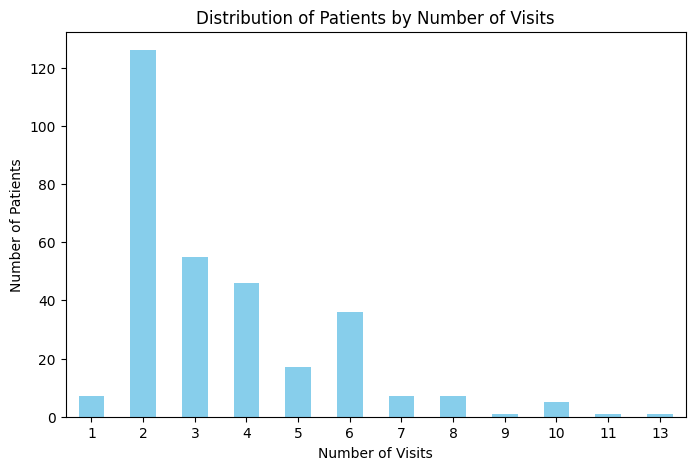

In [11]:
import matplotlib.pyplot as plt

#Count the number of visits per unique patient
visits_per_patient = df.groupby('patient_unique')['visit_number'].nunique().reset_index()

#Rename columns for clarity
visits_per_patient.columns = ['patient_unique', 'num_visits']

#Display the distribution of patients by number of visits
visit_distribution = visits_per_patient['num_visits'].value_counts().sort_index()

print("Number of patients by number of visits:")
print(visit_distribution)

#Plot as a bar chart
plt.figure(figsize=(8,5))
visit_distribution.plot(kind = 'bar', color = 'skyblue')
plt.title('Distribution of Patients by Number of Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 0)
plt.show()

After normalizing the `visit_number` for each unique patient, we verified the dataset counts. The total number of visits remains consistent at 1,097, matching the number of rows in the dataset, ensuring that all patient records have been retained correctly. Field data shows that patients often have more than five visits, contrary to what was initially assumed.

In [12]:
#Group by unique patient (based on combined info) and count the number of distinct clinics/hospitals
patient_clinic_counts = df.groupby('patient_unique')['clinic_name'].nunique().reset_index()

#Rename columns for clarity
patient_clinic_counts.columns = ['patient_unique', 'num_clinics']

#Filter patients who visited more than one clinic/hospital
patients_multiple_clinics = patient_clinic_counts[patient_clinic_counts['num_clinics'] > 1]

#Display the patients with more than one establishment
patients_multiple_clinics

,patient_unique,num_clinics
3,Abdou_Diouf_1990-07-07,2
113,Coumba_Samb_1995-10-10,2
125,Fatou_Dieng_1980-01-01,2
167,Khady_Diatta_1993-03-03,2
199,Mariam_Ndao_1999-09-09,2
228,Moustapha_Fall_1990-05-05,2
232,Nafissatou_Gaye_1985-12-12,2
236,Ndeye_Diop_1999-09-09,2
258,Oumou_Ba_1982-04-04,2
275,Serigne_Mbacke_1970-03-03,2


Some patients have visits recorded in multiple healthcare facilities, showing that they were followed across more than one clinic or hospital. This underscores the importance of a reliable unique patient identifier to consolidate their full medical history, avoid double-counting, and account for the decentralized nature of data collection. Linking patient records across facilities will support centralization and continuous improvement, facilitating future data management and analysis. Addressing this is essential to properly handle missing diagnoses and to respect the scope of this EDA exercise.

In [13]:
#Create a unique identifier for patient + visit
df['patient_visit_unique'] = (
    df['first_name'].astype(str).str.strip() + "_" +
    df['last_name'].astype(str).str.strip() + "_" +
    df['birth_date'].astype(str) + "_" +
    df['visit_date'].astype(str)
)

#Identify duplicates based on patient + visit
visit_duplicates = df[df.duplicated(subset='patient_visit_unique', keep=False)].sort_values('patient_visit_unique')

#Select only relevant columns
visit_duplicates_subset = visit_duplicates[['visit_date', 'first_name', 'last_name',
                                            'birth_date', 'clinic_name']]

#Display all the duplicates
pd.set_option('display.max_rows', 70)
print(visit_duplicates_subset)



      visit_date  first_name last_name  birth_date               clinic_name
1071  2024-05-01       Abdou      Diop  1990-07-07    Clinique Saint-Bernard
1095  2024-05-01       Abdou      Diop  1990-07-07    Clinique Saint-Bernard
620   2024-11-01       Abdou     Diouf  1990-07-07  West Karumo Medical Post
974   2024-11-01       Abdou     Diouf  1990-07-07    Clinique Saint-Bernard
1041  2024-09-01   Abdoulaye    Diagne  1990-10-10    Clinique Saint-Bernard
1085  2024-09-01   Abdoulaye    Diagne  1990-10-10    Clinique Saint-Bernard
106   2024-09-01       Aisha    Diallo  1995-04-12  Lake Abeni Health Center
205   2024-09-01       Aisha    Diallo  1995-04-12  Lake Abeni Health Center
1026  2024-04-15    Aissatou     Gueye  1985-12-12    Clinique Saint-Bernard
1080  2024-04-15    Aissatou     Gueye  1985-12-12    Clinique Saint-Bernard
1032  2024-06-15     Aminata    Ndiaye  1995-03-03    Clinique Saint-Bernard
1082  2024-06-15     Aminata    Ndiaye  1995-03-03    Clinique Saint-Bernard

To ensure accurate analysis of patient visits and diagnoses, we will first create a transfer column indicating whether a visit represents a transfer to another clinic, along with the transfer_clinic specifying the destination facility. After identifying these transfers, we will remove the corresponding rows as well as any true duplicate records. This cleanup will allow us to work with a consolidated and reliable dataset for the subsequent steps, including handling missing diagnoses.

In [14]:
#Initialize transfer columns
df['transfer'] = 'N'
df['transfer_clinic'] = pd.NA

#Sort to ensure consistent row ordering
df = df.sort_values(by=['patient_visit_unique', 'clinic_name'])

#Identify duplicates
duplicates = df[df.duplicated(subset = 'patient_visit_unique', keep = False)]

#Process duplicates group by group
for key, group in duplicates.groupby('patient_visit_unique'):
    
    clinics = group['clinic_name'].unique()
    idx = group.index.tolist()
    
    if len(clinics) > 1:
        #Transfer case
        row_keep = idx[0]       #Keep first row
        other_row = idx[1]      #Second row contains destination
        
        df.at[row_keep, 'transfer'] = 'Y'
        df.at[row_keep, 'transfer_clinic'] = df.at[other_row, 'clinic_name']
        
        #Remove second row
        df = df.drop(other_row)
    
    else:
        #True duplicate
        rows_to_drop = idx[1:]
        df = df.drop(rows_to_drop)

#Final cleaning: reset index
df = df.reset_index(drop = True)

#Reorder visits chronologically and renumber visit_number per patient
df = df.sort_values(by=['patient_unique', 'visit_date'])
df['visit_number'] = df.groupby('patient_unique').cumcount() + 1

#Validation check
remaining_duplicates = df.duplicated(subset='patient_visit_unique', keep=False).sum()
print("Remaining duplicates (should be 0):", remaining_duplicates)

Remaining duplicates (should be 0): 0


## 3.6-Missing diagnoses

Number of patients by distinct diagnoses across all visits:
num_unique_diagnoses
0     12
1    262
2     34
3      1
Name: count, dtype: int64


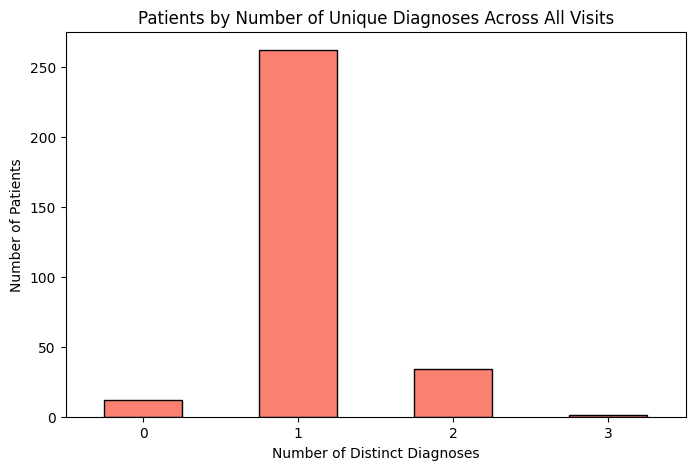

In [15]:
#Group by unique patient identifier and collect unique diagnoses
patient_diag_counts = (
    df.groupby('patient_unique')['diagnosis']
      .nunique(dropna=True)
      .reset_index()
)

#Rename columns for clarity
patient_diag_counts.columns = ['patient_unique', 'num_unique_diagnoses']

#Count patients by number of unique diagnoses
diagnosis_distribution = patient_diag_counts['num_unique_diagnoses'].value_counts().sort_index()

#Print the distribution
print("Number of patients by distinct diagnoses across all visits:")
print(diagnosis_distribution)

#Plot the distribution as a bar chart
plt.figure(figsize=(8,5))
diagnosis_distribution.plot(kind = 'bar', color = 'salmon', edgecolor = 'black')
plt.title('Patients by Number of Unique Diagnoses Across All Visits')
plt.xlabel('Number of Distinct Diagnoses')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 0)
plt.show()

We will first review patient medical records to recover missing diagnoses. Then, we will validate cases where a patient has multiple diagnoses to determine whether having three or more is clinically plausible, treating unlikely instances as errors.

In [16]:
#Group by unique patient identifier and check if all diagnoses are missing
patients_no_diagnosis = df.groupby('patient_unique').filter(lambda x: x['diagnosis'].isna().all())

#Display relevant columns to identify these patients
patients_no_diagnosis[['id_patient', 'first_name', 'last_name', 'birth_date', 'clinic_name']].drop_duplicates()

,id_patient,first_name,last_name,birth_date,clinic_name
57,1058,Adebayo,Adeyemi,1980-03-01,Lake Abeni Health Center
58,1144,Adebayo,Adeyemi,1980-03-01,Lake Abeni Health Center
59,1230,Adebayo,Adeyemi,1980-03-01,Lake Abeni Health Center
131,1291,Amadi,Okoro,1968-09-09,Lake Abeni Health Center
132,1033,Amadi,Okoro,1968-09-09,Lake Abeni Health Center
133,1119,Amadi,Okoro,1968-09-09,Lake Abeni Health Center
134,1205,Amadi,Okoro,1968-09-09,Lake Abeni Health Center
151,1078,Amara,Eze,1985-07-07,Lake Abeni Health Center
152,1164,Amara,Eze,1985-07-07,Lake Abeni Health Center
153,1250,Amara,Eze,1985-07-07,Lake Abeni Health Center


During the data quality review, we identified that all diagnostic recording irregularities were exclusively associated with **Lake Abeni Health Center**. An internal notification was sent to the facility, and a manual verification was conducted.

The facility confirmed that all affected patient records correspond to **malaria cases**, and that the inconsistencies were due to local data entry practices rather than clinical errors. No other clinics reported similar issues.

In [17]:
#Correct patients with 0 recorded diagnoses (validated as malaria cases)
df.loc[
    df.groupby('patient_unique')['diagnosis'].transform(lambda x: x.isna().all()),
    'diagnosis'
] = 'Malaria'

In [18]:
#Identify patients with exactly 3 distinct diagnoses
patients_with_3_diag = (
    df.groupby('patient_unique')
      .filter(lambda x: x['diagnosis'].nunique(dropna=True) == 3)
)

#Display their visits with diagnosis details
patients_with_3_diag[['id_patient', 'first_name', 'last_name', 'birth_date', 
                      'clinic_name','visit_date', 'diagnosis']].drop_duplicates()


,id_patient,first_name,last_name,birth_date,clinic_name,visit_date,diagnosis
393,P001,David,Okoro,1995-10-20,West Karumo Medical Post,2024-03-01,Malaria
394,P001,David,Okoro,1995-10-20,West Karumo Medical Post,2024-03-05,Malaria
395,P001,David,Okoro,1995-10-20,West Karumo Medical Post,2024-05-15,Malaria
396,P001,David,Okoro,1995-10-20,West Karumo Medical Post,2024-06-01,Malaria
397,P001,David,Okoro,1995-10-20,West Karumo Medical Post,2024-07-01,Typhoid
398,P001,David,Okoro,1995-10-20,West Karumo Medical Post,2024-08-01,Dengue


After reviewing the medical records for patient **P001**, we confirmed that the diagnosis of **Dengue** recorded on *2024-08-01* was entered in error. Clinical notes and the facility’s follow-up verification indicate that the patient was treated for **Typhoid only**, with no confirmed Dengue infection.

The incorrect entry has been flagged as a data recording issue and should not be considered a valid diagnosis.


In [19]:
#Correct the incorrect Dengue diagnosis for David Okoro on the 2024-08-01 visit
df.loc[
    (df["first_name"] == "David") &
    (df["last_name"] == "Okoro") &
    (df["visit_date"] == "2024-08-01") &
    (df["diagnosis"] == "Dengue"),
    "diagnosis"
] = "Typhoid"

Number of patients by distinct diagnoses across all visits:
num_unique_diagnoses
1    274
2     35
Name: count, dtype: int64


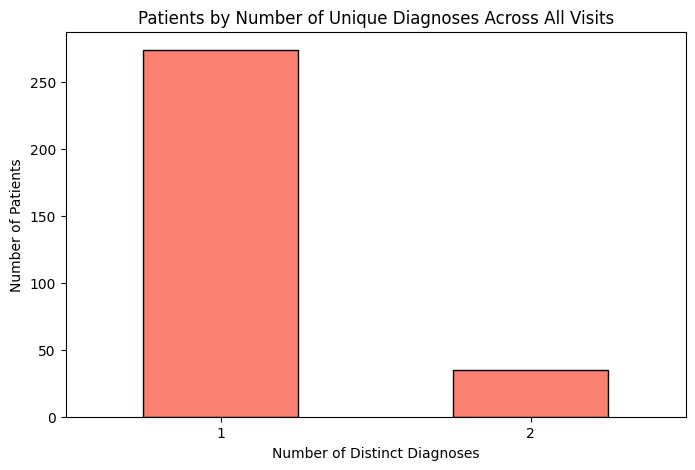

In [20]:
#Group by unique patient identifier and collect unique diagnoses
patient_diag_counts = (
    df.groupby('patient_unique')['diagnosis']
      .nunique(dropna=True)
      .reset_index()
)

#Rename columns for clarity
patient_diag_counts.columns = ['patient_unique', 'num_unique_diagnoses']

#Count patients by number of unique diagnoses
diagnosis_distribution = patient_diag_counts['num_unique_diagnoses'].value_counts().sort_index()

#Print the distribution
print("Number of patients by distinct diagnoses across all visits:")
print(diagnosis_distribution)

#Plot the distribution as a bar chart
plt.figure(figsize=(8,5))
diagnosis_distribution.plot(kind = 'bar', color = 'salmon', edgecolor = 'black')
plt.title('Patients by Number of Unique Diagnoses Across All Visits')
plt.xlabel('Number of Distinct Diagnoses')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 0)
plt.show()

In [21]:
# Sort visits chronologically per patient
df = df.sort_values(by=["patient_unique", "visit_date"]).reset_index(drop=True)

# Keep only the first occurrence of each diagnosis per patient
# Repeated diagnoses are replaced with NaN; all other rows remain
df["diagnosis"] = df.groupby("patient_unique")["diagnosis"].transform(
    lambda x: x.mask(x.duplicated())
)

# Quick checks
print("First 20 diagnosis entries:\n", df["diagnosis"].head(20))
print("Number of non-null diagnoses:", df["diagnosis"].notna().sum())

First 20 diagnosis entries:
 0     Malaria
1         NaN
2     Malaria
3         NaN
4     Typhoid
5     Malaria
6         NaN
7     Malaria
8         NaN
9     Typhoid
10    Malaria
11        NaN
12    Malaria
13        NaN
14        NaN
15    Malaria
16        NaN
17    Malaria
18        NaN
19     Dengue
Name: diagnosis, dtype: object
Number of non-null diagnoses: 344


## 3.7-Handling missing numerical values

In [22]:
#Select rows where either pulse or blood_pressure (systolic/diastolic) is missing
missing_clinical_data = df[df["pulse"].isna() | df["blood_pressure_systolic"].isna() | df["blood_pressure_diastolic"].isna()]

missing_clinical_data

,id_patient,visit_number,visit_date,clinic_name,patient_language,sex,birth_date,age,height,weight,...,blood_tests_required,imaging_required,first_name,last_name,blood_pressure_systolic,blood_pressure_diastolic,patient_unique,patient_visit_unique,transfer,transfer_clinic
84,P007,3,2024-06-20,Clinique Saint-Bernard,French,F,2000-03-01,24,168.0,70.0,...,NaN,NaN,Aisha,Bah,NaN,NaN,Aisha_Bah_2000-03-01,Aisha_Bah_2000-03-01_2024-06-20,N,<NA>
418,P003,3,2024-02-17,Clinique Saint-Bernard,French,F,2010-06-25,13,150.0,34.5,...,NaN,NaN,Fatou,Diallo,100.0,68.0,Fatou_Diallo_2010-06-25,Fatou_Diallo_2010-06-25_2024-02-17,N,<NA>
793,P003,2,2024-02-17,West Karumo Medical Post,English,F,2010-06-25,13,150.0,34.5,...,NaN,NaN,Ngozi,Chinedu,100.0,68.0,Ngozi_Chinedu_2010-06-25,Ngozi_Chinedu_2010-06-25_2024-02-17,N,<NA>


Missing values for vital signs will be imputed by calculating the average of the available recent measurements. Only stable patients with consistent other parameters will be considered to ensure reliable estimation. This approach minimizes errors from outdated or extreme values while reflecting the patient's typical condition.


In [23]:
#Filter visits for Aisha Bah born on 2000-03-01
aisha_visits = df[
    (df['first_name'] == 'Aisha') &
    (df['last_name'] == 'Bah') &
    (df['birth_date'] == '2000-03-01')
]

#Display the visits
print(aisha_visits)

   id_patient  visit_number  visit_date             clinic_name  \
82       P007             1  2024-06-10  Clinique Saint-Bernard   
83       P007             2  2024-06-15  Clinique Saint-Bernard   
84       P007             3  2024-06-20  Clinique Saint-Bernard   
85       P007             4  2024-07-01  Clinique Saint-Bernard   
86       P007             5  2024-07-15  Clinique Saint-Bernard   

   patient_language sex  birth_date  age  height  weight  ...  \
82           French   F  2000-03-01   24   168.0    70.0  ...   
83           French   F  2000-03-01   24   168.5    70.5  ...   
84           French   F  2000-03-01   24   168.0    70.0  ...   
85           French   F  2000-03-01   24   168.5    71.0  ...   
86           French   F  2000-03-01   24   169.0    71.5  ...   

    blood_tests_required  imaging_required  first_name last_name  \
82                   NaN               NaN       Aisha       Bah   
83                   NaN               NaN       Aisha       Bah   
84

In [24]:
#Her clinical parameters are nearly constant and she had no transfers : select Aisha Bah's visits
aisha = df[df['patient_unique'] == 'Aisha_Bah_2000-03-01'].sort_values('visit_date')

#Impute missing pulse and blood pressure using the mean of available previous visits
aisha['pulse'] = aisha['pulse'].fillna(aisha['pulse'].expanding().mean())
aisha['blood_pressure_systolic'] = aisha['blood_pressure_systolic'].fillna(aisha['blood_pressure_systolic'].expanding().mean())
aisha['blood_pressure_diastolic'] = aisha['blood_pressure_diastolic'].fillna(aisha['blood_pressure_diastolic'].expanding().mean())

df.update(aisha)
print(aisha[['blood_pressure_systolic', 'blood_pressure_diastolic']])

    blood_pressure_systolic  blood_pressure_diastolic
82                    120.0                      80.0
83                    120.0                      78.0
84                    120.0                      79.0
85                    118.0                      78.0
86                    120.0                      80.0


In [25]:
#Columns to display for clinical overview
cols = [
    'visit_number', 'visit_date', 'pulse', 
    'blood_pressure_systolic', 'blood_pressure_diastolic', 
    'temperature', 'oxygen_saturation', 'diagnosis', 
    'hospitalization_required', 
    'transfer'
]

#Filter visits for Fatou Diallo
fatou_visits = df[
    (df['first_name'] == 'Fatou') &
    (df['last_name'] == 'Diallo') &
    (df['birth_date'] == '2010-06-25')
]

#Display clinical parameters for Fatou Diallo
print(fatou_visits[cols])

#Filter visits for Ngozi Chinedu
ngozi_visits = df[
    (df['first_name'] == 'Ngozi') &
    (df['last_name'] == 'Chinedu') &
    (df['birth_date'] == '2010-06-25')
]

#Display clinical parameters for Ngozi Chinedu
print(ngozi_visits[cols])


     visit_number  visit_date  pulse  blood_pressure_systolic  \
416             1  2024-02-15  110.0                    105.0   
417             2  2024-02-16  105.0                    100.0   
418             3  2024-02-17    NaN                    100.0   
419             4  2024-03-01   95.0                    100.0   
420             5  2024-03-15   90.0                    100.0   

     blood_pressure_diastolic  temperature  oxygen_saturation diagnosis  \
416                      70.0         41.0                 85   Malaria   
417                      68.0         39.0                 92       NaN   
418                      68.0         37.0                 98       NaN   
419                      70.0         37.1                 99       NaN   
420                      70.0         37.0                 99       NaN   

    hospitalization_required transfer  
416                        Y        N  
417                        N        N  
418                        N        N 

In [26]:
#Again, their clinical parameters are nearly constant and they had no transfers

#Fatou Diallo
fatou = df[df['patient_unique'] == 'Fatou_Diallo_2010-06-25'].sort_values('visit_date')
#Impute missing pulse with mean of previous visits
fatou['pulse'] = fatou['pulse'].fillna(fatou['pulse'].expanding().mean())
df.update(fatou)
print(fatou[['visit_number','visit_date','pulse']])

#Ngozi Chinedu
ngozi = df[df['patient_unique'] == 'Ngozi_Chinedu_2010-06-25'].sort_values('visit_date')
#Impute missing pulse with mean of previous visits
ngozi['pulse'] = ngozi['pulse'].fillna(ngozi['pulse'].expanding().mean())
df.update(ngozi)
print(ngozi[['visit_number','visit_date','pulse']])

     visit_number  visit_date  pulse
416             1  2024-02-15  110.0
417             2  2024-02-16  105.0
418             3  2024-02-17  107.5
419             4  2024-03-01   95.0
420             5  2024-03-15   90.0
     visit_number  visit_date  pulse
792             1  2024-02-15  110.0
793             2  2024-02-17  110.0
794             3  2024-03-01   95.0
795             4  2024-03-15   90.0
796             5  2024-04-01   90.0


## 3.8-Handling Other Missing Values

In [27]:
#Fill missing hospitalization_days with 0
df['hospitalization_days'] = df['hospitalization_days'].fillna(0)

#Fill missing transfer_clinic with 'No transfer'
df['transfer_clinic'] = df['transfer_clinic'].fillna('No transfer')

## 3.9-Summary

In this notebook, we completed **Part 3 of the data cleaning pipeline**, which included:

- Identifying and handling duplicate visits, including detection of patient transfers across clinics.
- Reviewing and correcting missing or inconsistent clinical and diagnostic data, including initial imputation of vital signs for stable patients.
- Improving dataset integrity by addressing logical inconsistencies and recording errors.

## 3.10-Save Dataset

In [28]:
#Save df to a CSV file in Kaggle
df.to_csv("/kaggle/working/df.csv", index = False)

print("File saved as /kaggle/working/df.csv")

File saved as /kaggle/working/df.csv
